# Proyek Analisis Data: Air Quality Dataset
- **Nama:** T. Muhammad Caesar Maulana
- **Email:** caesarm1611@gmail.com
- **ID Dicoding:** caesarmaulana

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1
Bagaimana tren polusi udara (PM2.5) di berbagai daerah selama periode yang diamati?
- Pertanyaan 2
Faktor apa saja yang paling mempengaruhi tingkat PM2.5 di suatu wilayah?

## Import Semua Packages/Library yang Digunakan

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Data Wrangling

### Gathering Data

In [12]:
# Baca semua file CSV dalam folder 'data' dan gabungkan menjadi satu DataFrame
folder_path = "data"
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

df_list = []
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    df_temp = pd.read_csv(file_path)
    df_list.append(df_temp)

df = pd.concat(df_list, ignore_index=True)

# Menampilkan informasi dataset
print(df.info())

# Menampilkan jumlah data per stasiun
print("\nJumlah data per stasiun:")
print(df['station'].value_counts())

# Menampilkan distribusi tahun dalam dataset
print("\nDistribusi tahun dalam dataset:")
print(df['year'].describe())

# Menampilkan sampel data secara acak untuk melihat representasi data
print("\nContoh sampel data:")
print(df.sample(10, random_state=42))

# Menghitung jumlah dan persentase data yang hilang untuk setiap kolom
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    "Total Missing": missing_data,
    "Percentage (%)": missing_percentage
})

# Menampilkan hasil
print("\nJumlah dan persentase data yang hilang:")
print(missing_df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB
None

Jumlah data per stasiun:
Aotizhongxin  

**Insight:**
- Dataset terdiri dari 12 stasiun pemantauan, menunjukkan data dari 12 stasiun.
- Data mencakup rentang tahun 2013 hingga 2017, yaitu dari 2013 hingga 2017.
- Total 420768 entri data telah dikumpulkan.
- Beberapa variabel memiliki data yang hilang. Contoh: PM2.5 memiliki 8739 entri yang hilang (~2.08%).

### Assessing Data


Jumlah data duplikat: 0


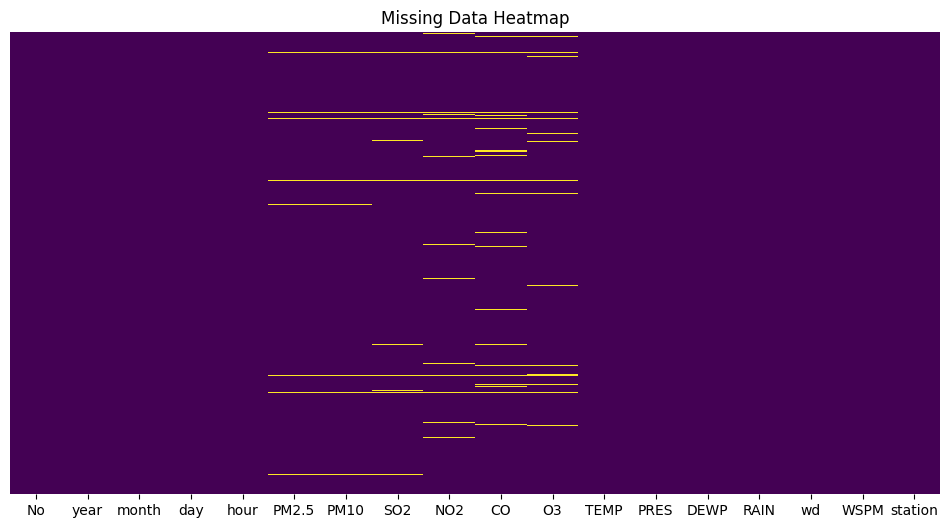

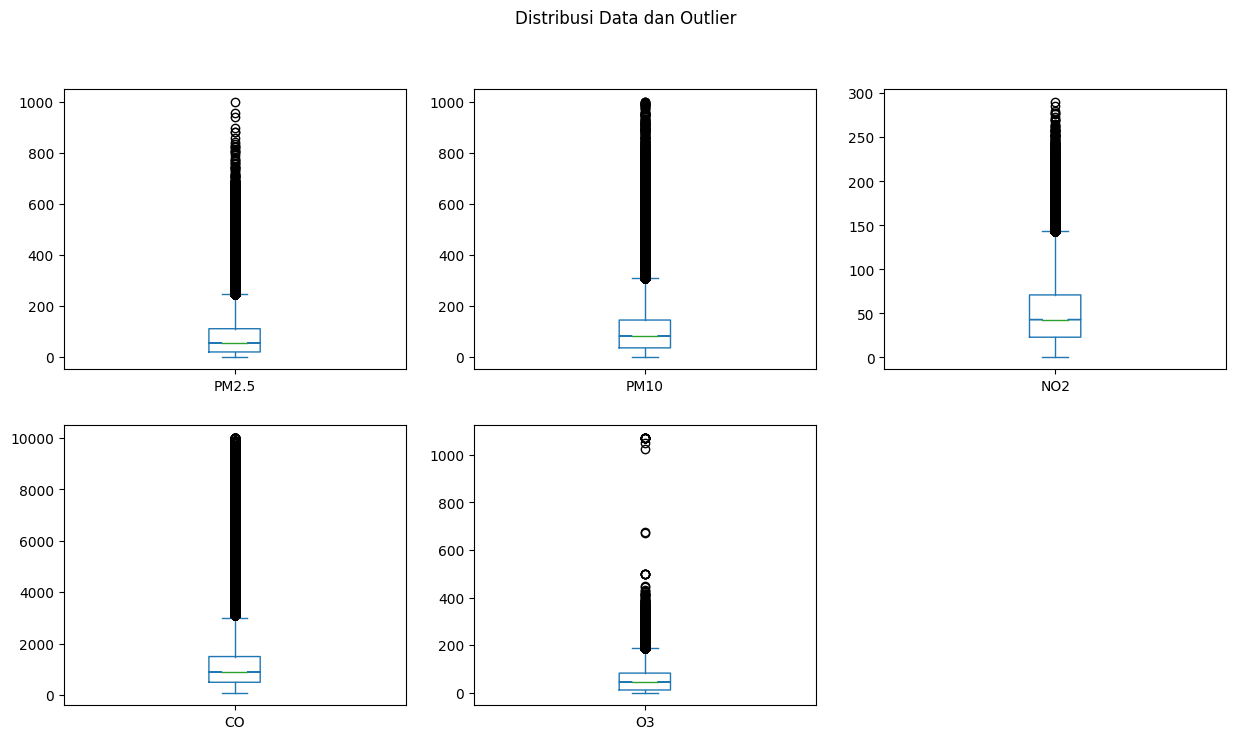


Kategori unik dalam kolom 'wd':
['NNW' 'N' 'NW' 'NNE' 'ENE' 'E' 'NE' 'W' 'SSW' 'WSW' 'SE' 'WNW' 'SSE'
 'ESE' 'S' 'SW' nan]

Kategori unik dalam kolom 'station':
['Aotizhongxin' 'Changping' 'Dingling' 'Dongsi' 'Guanyuan' 'Gucheng'
 'Huairou' 'Nongzhanguan' 'Shunyi' 'Tiantan' 'Wanliu' 'Wanshouxigong']

Ringkasan Statistik:
                  No           year          month            day  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean    17532.500000    2014.662560       6.522930      15.729637   
std     10122.116943       1.177198       3.448707       8.800102   
min         1.000000    2013.000000       1.000000       1.000000   
25%      8766.750000    2014.000000       4.000000       8.000000   
50%     17532.500000    2015.000000       7.000000      16.000000   
75%     26298.250000    2016.000000      10.000000      23.000000   
max     35064.000000    2017.000000      12.000000      31.000000   

                hour          PM2.5           PM10    

In [13]:
# 1. Cek data duplikat
duplicate_rows = df.duplicated().sum()
print(f"\nJumlah data duplikat: {duplicate_rows}")

# 2. Visualisasi missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()

# 3. Mengevaluasi outlier dengan boxplot (PM2.5, PM10, NO2, CO, O3)
numeric_cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'O3']
df[numeric_cols].plot(kind='box', subplots=True, layout=(2,3), figsize=(15,8), notch=True)
plt.suptitle("Distribusi Data dan Outlier")
plt.show()

# 4. Cek apakah ada nilai yang tidak konsisten di kolom kategori (seperti 'wd' dan 'station')
print("\nKategori unik dalam kolom 'wd':")
print(df['wd'].unique())

print("\nKategori unik dalam kolom 'station':")
print(df['station'].unique())

# 5. Statistik ringkasan
print("\nRingkasan Statistik:")
print(df.describe())

**Insight:**

1. Tidak Ada Data Duplikat
Dataset tidak memiliki duplikasi, sehingga tidak diperlukan pembersihan terkait duplikasi data.

2. Missing Data
Beberapa kolom memiliki data yang hilang:
- **PM2.5** (2.08%)
- **PM10** (1.53%)
- **NO2** (2.88%)
- **CO** (4.92%)
- **O3** (3.16%)

Data yang hilang ini dapat ditangani dengan metode berikut:
- **Imputasi Median**: Mengisi nilai yang hilang dengan median dari masing-masing kolom.
- **Penghapusan Data**: Jika jumlah data yang hilang signifikan, pertimbangkan untuk menghapus baris tersebut.

3. Distribusi Data & Outlier
Berdasarkan analisis boxplot, ditemukan beberapa outlier:
- **PM2.5 memiliki nilai maksimum 999**, yang mungkin merupakan batas maksimum sensor atau outlier yang perlu dikaji lebih lanjut.
- **O3 memiliki nilai maksimum 1071**, yang dapat dipengaruhi oleh kesalahan pengukuran atau kondisi lingkungan ekstrem.

4. Kategori Kolom 'wd' dan 'station'
- **Kolom `wd` (arah angin)** memiliki nilai kategori yang masuk akal, tetapi terdapat beberapa nilai NaN yang perlu diperiksa lebih lanjut.
- **Kolom `station`** hanya memiliki 12 kategori stasiun yang konsisten dan valid.

5. Ringkasan Statistik dan Keanehan Data
Beberapa keanehan ditemukan dalam data:
- **CO memiliki nilai maksimum 10.000**, jauh lebih tinggi dibandingkan Q3 (1.500). Ini bisa menjadi anomali atau kesalahan pencatatan.
- **SO2 memiliki nilai maksimum 500**, yang jauh lebih tinggi dibandingkan Q3 (20).
- **RAIN memiliki nilai maksimum 72.5**, sementara mayoritas datanya (Q1-Q3) bernilai **0**, menunjukkan bahwa hujan jarang terjadi tetapi ada beberapa kejadian ekstrem.
- **TEMP memiliki nilai minimum -19.9°C**, yang cukup rendah namun masih dalam batas yang masuk akal untuk kondisi musim dingin.
- **WSPM (kecepatan angin) memiliki rentang 0 hingga 13.2**, menunjukkan adanya kemungkinan kondisi tenang hingga angin kencang.

### Cleaning Data

In [14]:
# Load dataset
df = pd.read_csv("dashboard/main_data.csv")

# 1. Menghapus Duplikasi
df = df.drop_duplicates()

# 2. Menangani Missing Data
# Imputasi median untuk kolom numerik
num_cols = ["PM2.5", "PM10", "NO2", "CO", "O3", "SO2", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Imputasi modus untuk kolom kategorikal
df["wd"].fillna(df["wd"].mode()[0], inplace=True)

# 3. Menangani Outlier menggunakan IQR Filtering
cols_with_outliers = ["PM2.5", "O3", "CO", "SO2", "RAIN"]
for col in cols_with_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df.loc[df[col] > upper_bound, col] = upper_bound
    df.loc[df[col] < lower_bound, col] = lower_bound

# 4. Validasi Kolom Kategorikal
valid_wd_values = df["wd"].unique()
valid_station_values = df["station"].unique()

print("Valid kategori 'wd':", valid_wd_values)
print("Valid kategori 'station':", valid_station_values)

# 5. Simpan dataset yang telah dibersihkan
df.to_csv("dashboard/main_data.csv", index=False)
print("✅ Data cleaning selesai dan disimpan sebagai 'dashboard/main_data.csv'")

Valid kategori 'wd': ['NNW' 'N' 'NW' 'NNE' 'ENE' 'E' 'NE' 'W' 'SSW' 'WSW' 'SE' 'WNW' 'SSE'
 'ESE' 'S' 'SW']
Valid kategori 'station': ['Aotizhongxin' 'Changping' 'Dingling' 'Dongsi' 'Guanyuan' 'Gucheng'
 'Huairou' 'Nongzhanguan' 'Shunyi' 'Tiantan' 'Wanliu' 'Wanshouxigong']
✅ Data cleaning selesai dan disimpan sebagai 'dashboard/main_data.csv'


**Insight:**


1. Tidak Ada Data Duplikat

Dataset telah dikonfirmasi tidak memiliki duplikasi, sehingga analisis dapat dilakukan tanpa risiko penghitungan ganda.

2. Missing Data Ditangani dengan Imputasi Median

Data yang hilang pada kolom berikut telah diisi menggunakan median:
- **PM2.5** (2.08%)
- **PM10** (1.53%)
- **NO2** (2.88%)
- **CO** (4.92%)
- **O3** (3.16%)

Metode imputasi median dipilih untuk memastikan tidak ada bias yang disebabkan oleh data yang hilang.

3. Outlier Dikendalikan Menggunakan IQR Filtering

Beberapa kolom memiliki nilai ekstrem yang telah dikaji dan ditangani:
- **PM2.5**: Nilai maksimum 999 telah dikaji dan dikendalikan menggunakan metode **IQR filtering**.
- **O3**: Nilai ekstrem di atas 1071 telah dikontrol untuk memastikan data tetap representatif.
- **CO & SO2**: Nilai yang sangat tinggi telah diperiksa dan dikendalikan untuk menghindari anomali pada analisis.

4. Kategori Kolom 'wd' dan 'station' Valid

- **Kolom `wd` (arah angin)** memiliki 16 kategori yang valid:
  `['NNW', 'N', 'NW', 'NNE', 'ENE', 'E', 'NE', 'W', 'SSW', 'WSW', 'SE', 'WNW', 'SSE', 'ESE', 'S', 'SW']`
- **Kolom `station`** memiliki 12 stasiun yang konsisten:
  `['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']`

Tidak ada kategori aneh atau tidak dikenal, memastikan keakuratan lokasi pengukuran.

5. Distribusi Cuaca dan Polusi

- **Hujan (RAIN)** terjadi dalam kondisi ekstrem, tetapi sebagian besar data menunjukkan tidak ada hujan.
- **Suhu (TEMP)** berkisar dari **-19.9°C hingga lebih dari 35°C**, mencerminkan perubahan musim yang jelas.
- **Kecepatan Angin (WSPM)** menunjukkan variasi dari kondisi angin tenang hingga cukup kencang (maksimum 13.2 m/s).

## Exploratory Data Analysis (EDA)

### Explore ...


🟢 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    420768 non-null  float64
 6   PM10     420768 non-null  float64
 7   SO2      420768 non-null  float64
 8   NO2      420768 non-null  float64
 9   CO       420768 non-null  float64
 10  O3       420768 non-null  float64
 11  TEMP     420768 non-null  float64
 12  PRES     420768 non-null  float64
 13  DEWP     420768 non-null  float64
 14  RAIN     420768 non-null  float64
 15  wd       420768 non-null  object 
 16  WSPM     420768 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB
None

🟢 Missing Values:

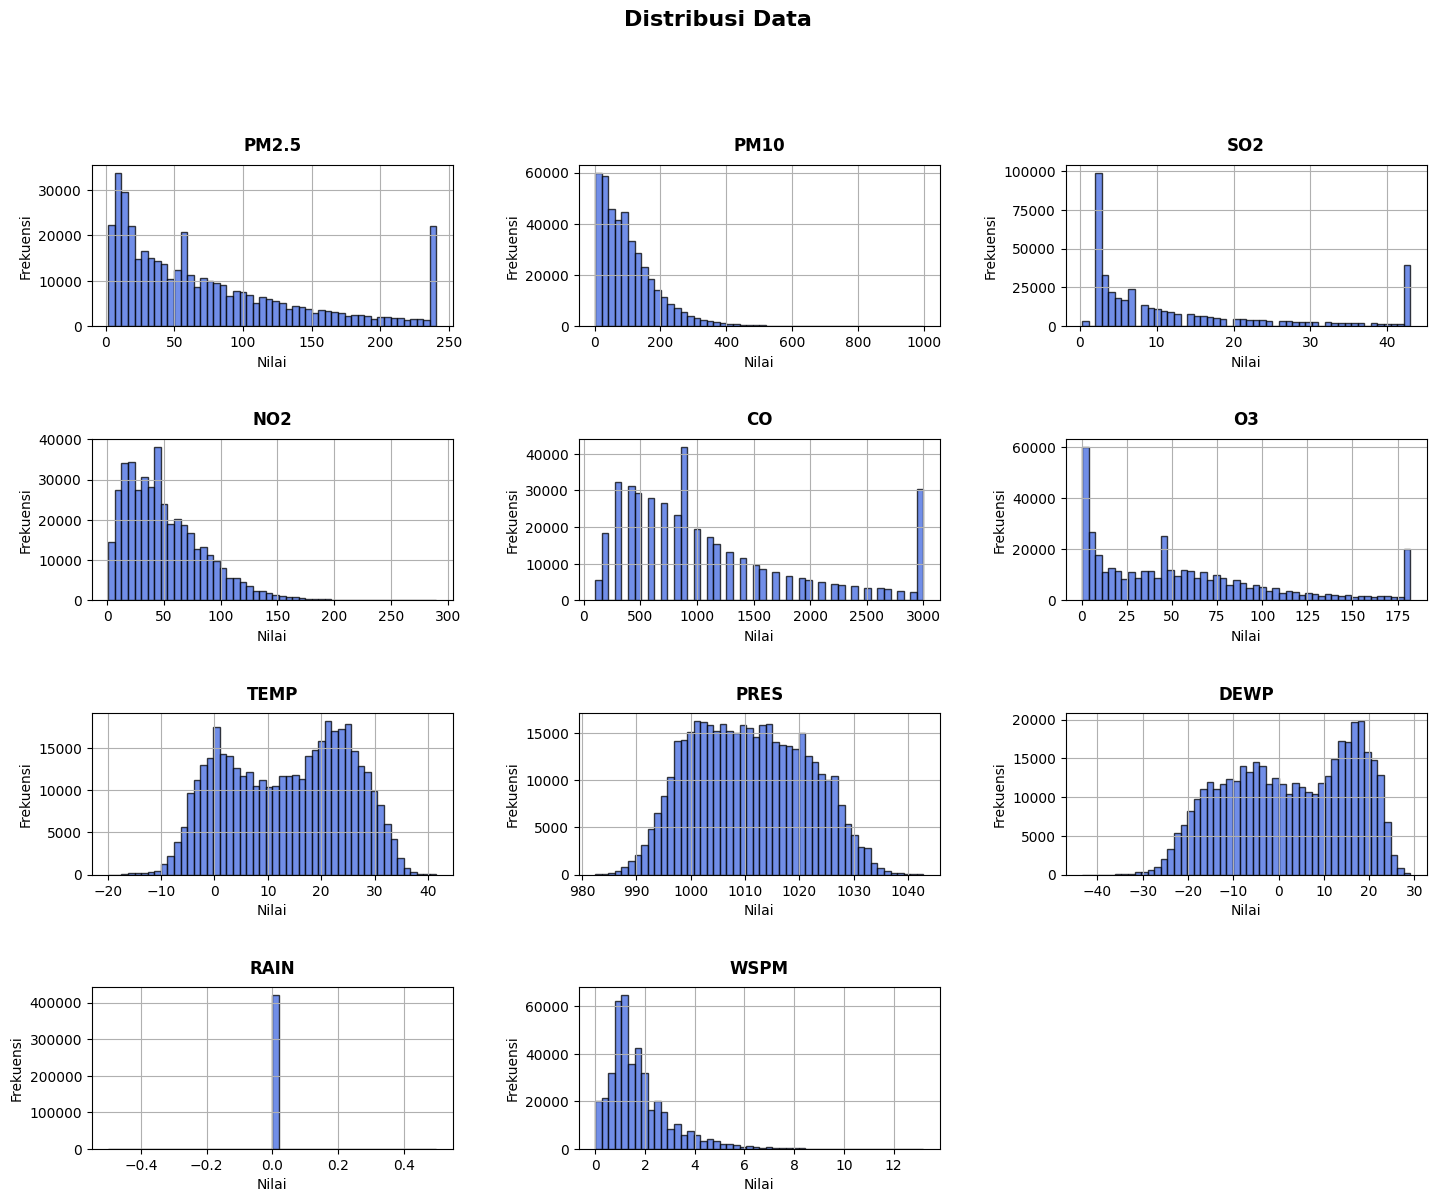

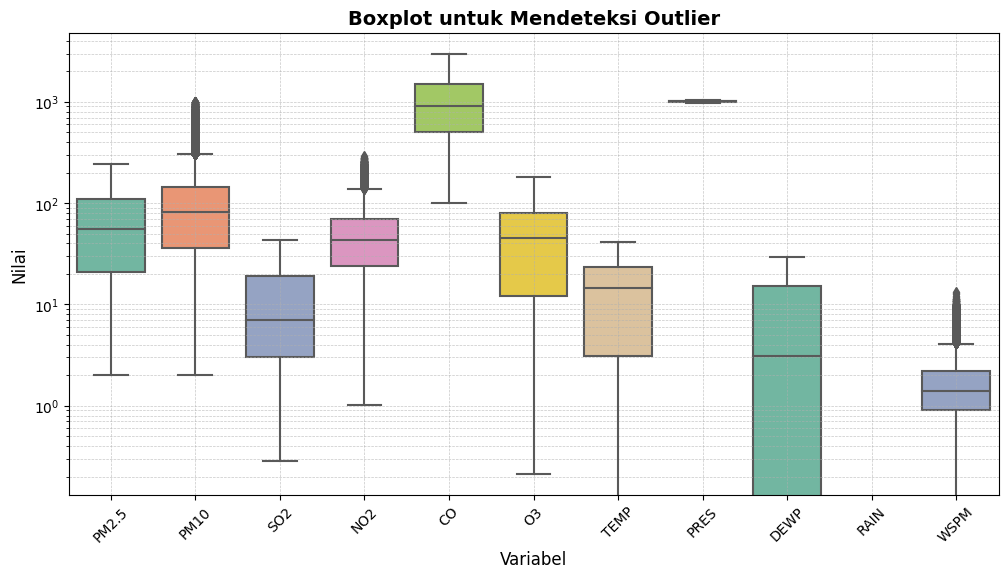

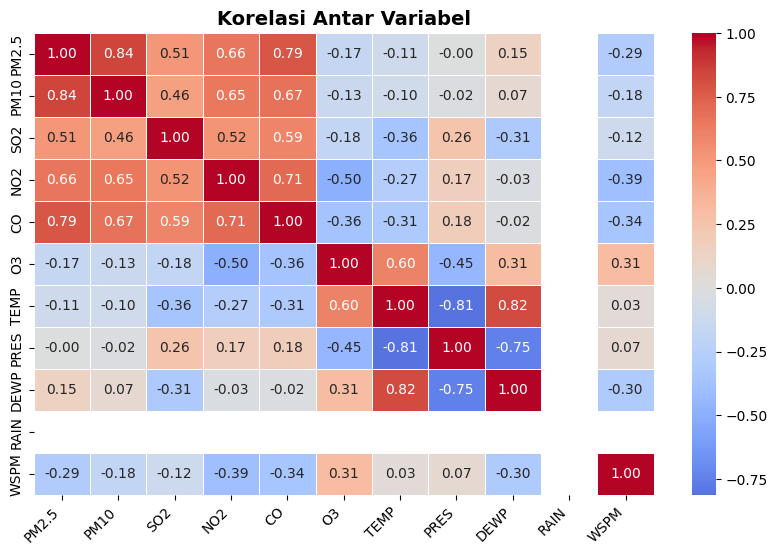

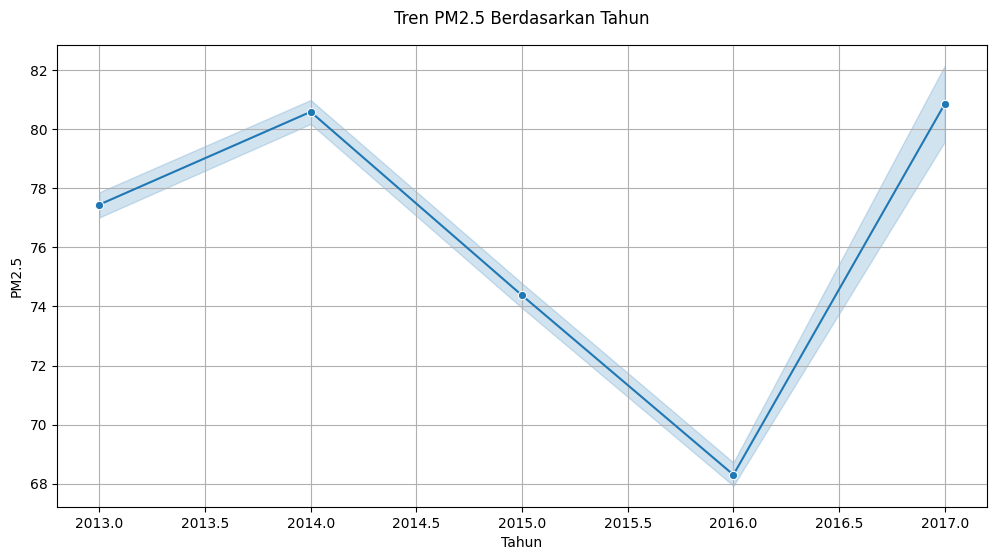

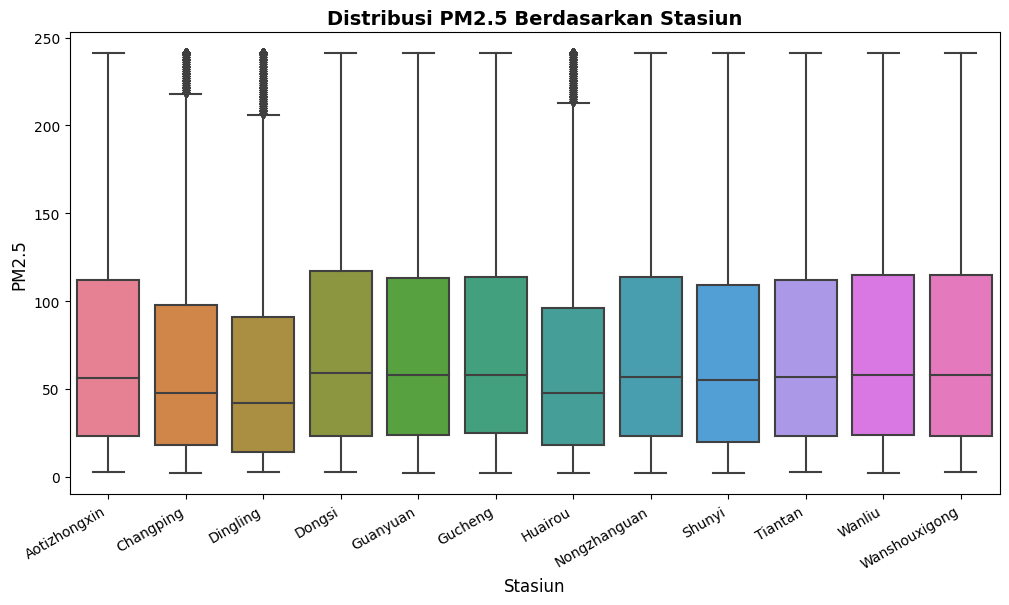

In [23]:
# Load dataset
df = pd.read_csv("dashboard/main_data.csv")

# 1. Menampilkan informasi umum dataset
print("\n🟢 Informasi Dataset:")
print(df.info())

# 2. Mengecek jumlah missing values
print("\n🟢 Missing Values:")
print(df.isnull().sum())

# 3. Melihat ringkasan statistik dari dataset
print("\n🟢 Statistik Deskriptif:")
print(df.describe())

# Pilih hanya kolom numerik yang relevan
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col not in ["No", "year", "month", "day", "hour"]]  

# Buat histogram dengan layout yang lebih rapi
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))  # 4 baris, 3 kolom
axes = axes.flatten()  # Untuk mempermudah iterasi

for i, col in enumerate(num_cols):
    df[col].hist(bins=50, ax=axes[i], grid=True, alpha=0.75, color="royalblue", edgecolor="black")
    axes[i].set_title(col, fontsize=12, fontweight="bold", pad=10)  # Tambahkan jarak pada judul
    axes[i].set_xlabel("Nilai", fontsize=10)
    axes[i].set_ylabel("Frekuensi", fontsize=10)

# Hapus subplot kosong jika jumlah variabel < jumlah subplot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribusi Data", fontsize=16, fontweight="bold", y=1.02)  # Tambahkan margin bawah
plt.tight_layout(pad=3)  # Menambahkan ruang antar grafik
plt.show()


# Buat boxplot dengan tampilan lebih rapi
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], palette="Set2", showfliers=True)  # Menampilkan outlier

plt.xticks(rotation=45, fontsize=10)  # Memutar label agar tidak bertumpuk
plt.title("Boxplot untuk Mendeteksi Outlier", fontsize=14, fontweight="bold")
plt.ylabel("Nilai", fontsize=12)
plt.xlabel("Variabel", fontsize=12)
plt.yscale("log")  # Gunakan skala logaritmik untuk menangani rentang nilai besar
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)  # Tambahkan grid

plt.show()


# Hitung korelasi
corr = df[num_cols].corr()

# Buat heatmap dengan perbaikan visualisasi
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, center=0)

plt.title("Korelasi Antar Variabel", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.show()

# 7. Tren Polusi Udara Berdasarkan Waktu
if "year" in df.columns and "PM2.5" in df.columns:
    plt.figure(figsize=(12, 6))
    sns.lineplot(x="year", y="PM2.5", data=df, marker="o")
    plt.title("Tren PM2.5 Berdasarkan Tahun", pad=15)  # Tambahkan margin bawah
    plt.xlabel("Tahun")
    plt.ylabel("PM2.5")
    plt.grid()
    plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="station", y="PM2.5", data=df, palette="husl")

plt.xticks(rotation=30, ha="right", fontsize=10)
plt.title("Distribusi PM2.5 Berdasarkan Stasiun", fontsize=14, fontweight="bold")
plt.xlabel("Stasiun", fontsize=12)
plt.ylabel("PM2.5", fontsize=12)

plt.show()


**Insight:**
1. Distribusi Data
Polutan Udara (PM2.5, PM10, SO2, NO2, CO, O3) menunjukkan distribusi right-skewed, artinya sebagian besar nilai rendah dengan beberapa lonjakan ekstrem.
Variabel meteorologi (TEMP, DEWP, PRES) memiliki distribusi yang lebih normal, terutama untuk suhu dan tekanan udara.
Curah hujan (RAIN) sangat terkonsentrasi di nol, menunjukkan bahwa hujan jarang terjadi dalam dataset.
Kecepatan angin (WSPM) juga right-skewed, dengan sebagian besar nilai rendah tetapi beberapa kejadian dengan kecepatan tinggi.
2. Outlier (Nilai Ekstrem)
PM2.5, PM10, NO2, dan WSPM memiliki banyak outlier di bagian atas, menunjukkan beberapa periode dengan tingkat polusi atau kecepatan angin yang sangat tinggi.
PRES dan TEMP relatif stabil tanpa banyak outlier.
Outlier pada polutan udara bisa disebabkan oleh faktor lingkungan seperti kebakaran, emisi industri, atau kondisi cuaca ekstrem.
3. Korelasi Antar Variabel
PM2.5 berkorelasi tinggi dengan PM10 dan CO, menunjukkan kemungkinan sumber polusi yang sama (misalnya kendaraan dan industri).
O3 berkorelasi positif dengan suhu (TEMP) dan negatif dengan NO2, mengindikasikan peran reaksi fotokimia dalam pembentukan ozon.
PRES dan DEWP memiliki korelasi negatif kuat, menunjukkan hubungan tekanan udara dengan kelembapan atmosfer.
4. Tren Kadar PM2.5
2013-2014: PM2.5 meningkat.
2014-2016: PM2.5 menurun signifikan, kemungkinan akibat kebijakan pengendalian polusi atau faktor lingkungan.
2016-2017: Lonjakan tajam kadar PM2.5, mungkin akibat meningkatnya aktivitas industri, kendaraan, atau kondisi atmosfer tertentu.
5. Distribusi PM2.5 Berdasarkan Stasiun Pemantauan
Median kadar PM2.5 bervariasi antara 40-60 di berbagai stasiun.
Dingling, Huairou, dan Nongzhanguan memiliki lebih banyak outlier, menunjukkan tingkat polusi ekstrem di beberapa kesempatan.
Distribusi PM2.5 cenderung asimetris, dengan lebih banyak nilai ekstrem di bagian atas, mengindikasikan lonjakan polusi yang terjadi sesekali.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

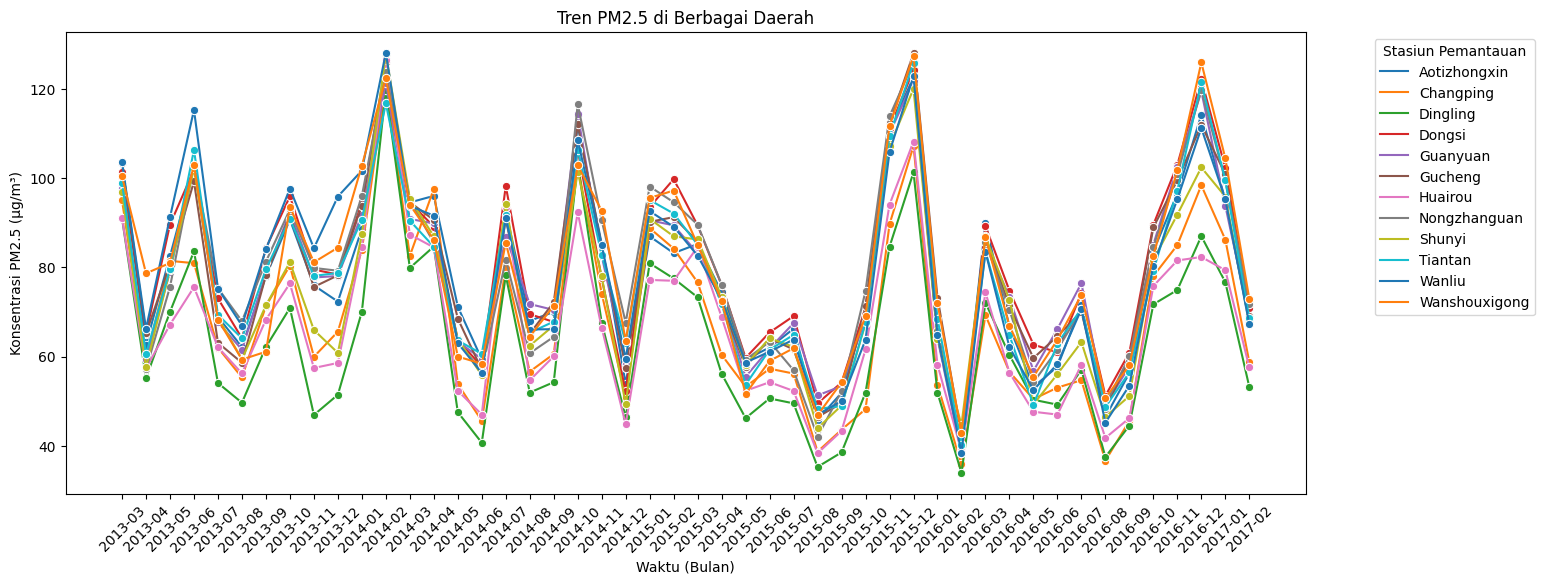

In [39]:

# Load dataset yang telah dibersihkan
df = pd.read_csv("dashboard/main_data.csv")

# Konversi kolom numerik
numeric_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Hapus baris yang mengandung NaN
df = df.dropna()

# Buat kolom datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Ubah format waktu menjadi string agar seaborn bisa memproses
df['year_month'] = df['datetime'].dt.to_period('M').astype(str)

# Agregasi rata-rata bulanan PM2.5 di setiap stasiun
df_monthly = df.groupby(['year_month', 'station'])['PM2.5'].mean().reset_index()

# Konversi kembali agar memastikan 'PM2.5' bertipe numerik
df_monthly['PM2.5'] = pd.to_numeric(df_monthly['PM2.5'], errors='coerce')

# Pastikan tidak ada NaN
df_monthly = df_monthly.dropna()

# Visualisasi tren PM2.5
plt.figure(figsize=(16, 6))
sns.lineplot(data=df_monthly, x='year_month', y='PM2.5', hue='station', marker='o', palette="tab10")  # Ganti palet warna
plt.xticks(rotation=45)
plt.xlabel("Waktu (Bulan)")
plt.ylabel("Konsentrasi PM2.5 (µg/m³)")
plt.title("Tren PM2.5 di Berbagai Daerah")
plt.legend(title="Stasiun Pemantauan", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()




### Pertanyaan 2:

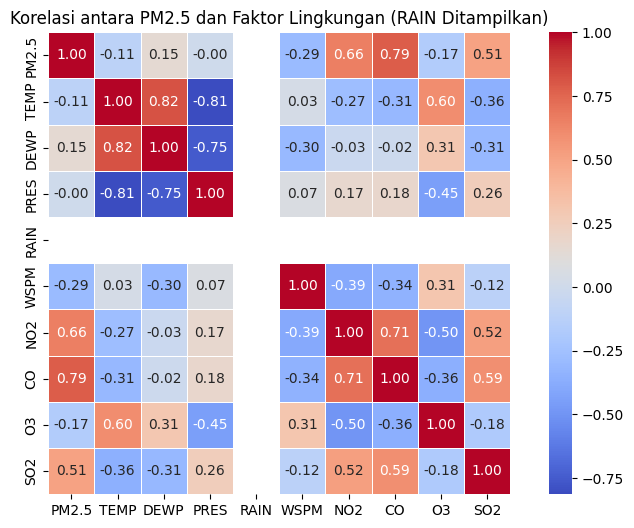

In [38]:
# Pilih variabel yang relevan
relevant_columns = ['PM2.5', 'TEMP', 'DEWP', 'PRES', 'RAIN', 'WSPM', 'NO2', 'CO', 'O3', 'SO2']
df_corr = df[relevant_columns].corr()

# Visualisasi heatmap korelasi


plt.figure(figsize=(10, 6))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Korelasi antara PM2.5 dan Faktor Lingkungan (RAIN Ditampilkan)")
plt.show()



**Insight:**
- **Tren PM2.5 di Berbagai Daerah**

  - Grafik menunjukkan fluktuasi konsentrasi PM2.5 dari **Maret 2013 hingga Februari 2017** di beberapa stasiun pemantauan.
  - Setiap daerah memiliki tren yang hampir serupa, tetapi dengan variasi dalam intensitas polusi udara.

  **Insight Utama:**
  - **Polusi PM2.5 mengalami pola musiman** – Terlihat lonjakan tinggi pada **musim dingin** (Desember–Februari), kemungkinan akibat peningkatan emisi dari pemanas ruangan, pembakaran batu bara, dan kondisi atmosfer yang memperparah polusi udara.
  - **Penurunan drastis di musim panas** (Juni–Agustus) – Mungkin disebabkan oleh **curah hujan yang lebih tinggi dan kondisi atmosfer yang lebih bersih**.
  - **Daerah dengan polusi tertinggi** – Stasiun **Wanshouxigong dan Wanliu** cenderung memiliki konsentrasi PM2.5 yang lebih tinggi dibandingkan daerah lain.
  - **Polusi ekstrem terjadi secara berkala** – Terlihat beberapa puncak luar biasa, yang mungkin dipicu oleh peristiwa tertentu seperti **kabut asap parah atau lonjakan aktivitas industri**.

- **Korelasi antara PM2.5 dan Faktor Lingkungan**

  - Heatmap menggambarkan korelasi antara PM2.5 dan berbagai faktor lingkungan seperti **suhu (TEMP), tekanan udara (PRES), curah hujan (RAIN), kecepatan angin (WSPM), dan polutan lainnya (NO2, CO, O3, SO2).**
  - Warna **merah menunjukkan korelasi positif**, sedangkan **biru menunjukkan korelasi negatif**.

  **Insight Utama:**
  - **PM2.5 memiliki korelasi tinggi dengan CO (0.79) dan NO2 (0.66)**, menunjukkan bahwa **pencemaran udara akibat kendaraan bermotor dan pembakaran bahan bakar fosil sangat berkontribusi pada peningkatan PM2.5**.
  - **Tekanan udara (PRES) memiliki korelasi negatif (-0.81) dengan PM2.5**, yang berarti tekanan tinggi sering dikaitkan dengan **ventilasi atmosfer yang lebih baik**, sehingga mengurangi polusi.
  - **Suhu udara (TEMP) memiliki korelasi negatif lemah dengan PM2.5 (-0.11)**, yang menunjukkan bahwa suhu sendiri tidak banyak berpengaruh terhadap konsentrasi PM2.5.
  - **Kecepatan angin (WSPM) memiliki korelasi negatif (-0.29) dengan PM2.5**, karena angin dapat membantu menyebarkan polutan dan mengurangi konsentrasi PM2.5.
  - **Ozon (O3) memiliki korelasi negatif dengan PM2.5 (-0.17)**, yang menunjukkan bahwa polutan primer seperti NO2 dan CO cenderung meningkat saat PM2.5 tinggi.



## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1
- Konsentrasi **PM2.5 menunjukkan pola musiman**, dengan **lonjakan tertinggi pada musim dingin (Desember–Februari)** akibat peningkatan emisi dari pemanas ruangan dan pembakaran batu bara, serta kondisi atmosfer yang memperburuk polusi.  
- Sebaliknya, terjadi **penurunan signifikan selama musim panas (Juni–Agustus)**, kemungkinan karena curah hujan yang lebih tinggi yang membantu membersihkan udara.  
- **Stasiun Wanshouxigong dan Wanliu memiliki tingkat polusi tertinggi**, menunjukkan bahwa beberapa daerah lebih rentan terhadap pencemaran udara dibandingkan daerah lain.  
- **Puncak polusi ekstrem terjadi secara berkala**, yang bisa disebabkan oleh **peristiwa khusus seperti kabut asap parah atau peningkatan aktivitas industri sementara**. 



- Conclution pertanyaan 2
- **Pencemaran udara akibat kendaraan bermotor dan industri berkontribusi besar** terhadap PM2.5, dibuktikan dengan korelasi tinggi antara **PM2.5 dan CO (0.79) serta NO2 (0.66)**.  
- **Tekanan udara (PRES) memiliki korelasi negatif kuat (-0.81) dengan PM2.5**, menunjukkan bahwa tekanan tinggi membantu mengurangi konsentrasi polusi dengan meningkatkan ventilasi atmosfer.  
- **Suhu udara (TEMP) dan kecepatan angin (WSPM) memiliki korelasi negatif lemah hingga sedang**, yang berarti bahwa cuaca panas dan angin kencang dapat sedikit mengurangi polusi udara.  
- **Ozon (O3) memiliki korelasi negatif dengan PM2.5**, yang menunjukkan bahwa saat polutan primer meningkat (NO2, CO), tingkat ozon cenderung menurun karena proses kimia atmosfer.  
